<a href="https://colab.research.google.com/github/anishbhujbal7/covid19-ct-scan-classification/blob/main/covid19_ct_scan_classfication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

dataset taken from https://www.kaggle.com/datasets/plameneduardo/sarscov2-ctscan-dataset

In [ ]:
file_path='/content/drive/MyDrive/colab_datasets/covid-ct-scans/archive.zip'
from zipfile import ZipFile
with ZipFile(file_path,'r') as zip:
  zip.extractall()
  print('Done')

Done


In [ ]:
import os
import shutil
import random

# Set seed for reproducibility
random.seed(42)

# Original dataset folders
covid_src = "/content/COVID"
noncovid_src = "/content/non-COVID"

# 1] Create new directories for storing the unzipped data

In [ ]:
base_dir = "/content/ct-scans"
train_covid = os.path.join(base_dir, "train/covid-train")
train_noncovid = os.path.join(base_dir, "train/noncovid-train")
test_covid = os.path.join(base_dir, "test/covid-test")
test_noncovid = os.path.join(base_dir, "test/noncovid-test")

#### mark the created directories

In [ ]:
os.makedirs(train_covid, exist_ok=True)
os.makedirs(train_noncovid, exist_ok=True)
os.makedirs(test_covid, exist_ok=True)
os.makedirs(test_noncovid, exist_ok=True)


#### populate the directories according to test size and training size

In [ ]:
def split_and_move(src_dir, train_dir, test_dir, split_ratio=0.8):
    files = os.listdir(src_dir)
    random.shuffle(files)

    split_index = int(len(files) * split_ratio)
    train_files = files[:split_index]
    test_files = files[split_index:]

    for f in train_files:
        shutil.move(os.path.join(src_dir, f), os.path.join(train_dir, f))

    for f in test_files:
        shutil.move(os.path.join(src_dir, f), os.path.join(test_dir, f))

In [ ]:
split_and_move(covid_src, train_covid, test_covid)
split_and_move(noncovid_src, train_noncovid, test_noncovid)

print("Dataset successfully split and organized into /content/ct-scans/")

Dataset successfully split and organized into /content/ct-scans/


# 2] Exploratory Data Analysis (EDA)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

In [ ]:
base_dir = "/content/ct-scans"

# Check folder structure
folders = os.listdir(base_dir)
print("Folders in the base directory:", folders)

train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

train_folders = os.listdir(train_dir)
test_folders = os.listdir(test_dir)

print("Train Folders:", train_folders)
print("Test Folders:", test_folders)


Folders in the base directory: ['train', 'test']
Train Folders: ['noncovid-train', 'covid-train']
Test Folders: ['noncovid-test', 'covid-test']


## Image Count Analysis

In [ ]:
# Count images in each folder
covid_train_count = len(os.listdir(os.path.join(train_dir, "covid-train")))
noncovid_train_count = len(os.listdir(os.path.join(train_dir, "noncovid-train")))

covid_test_count = len(os.listdir(os.path.join(test_dir, "covid-test")))
noncovid_test_count = len(os.listdir(os.path.join(test_dir, "noncovid-test")))

print(f"COVID Train Count: {covid_train_count}")
print(f"Non-COVID Train Count: {noncovid_train_count}")
print(f"COVID Test Count: {covid_test_count}")
print(f"Non-COVID Test Count: {noncovid_test_count}")


COVID Train Count: 1001
Non-COVID Train Count: 983
COVID Test Count: 251
Non-COVID Test Count: 246


## Class Distribution

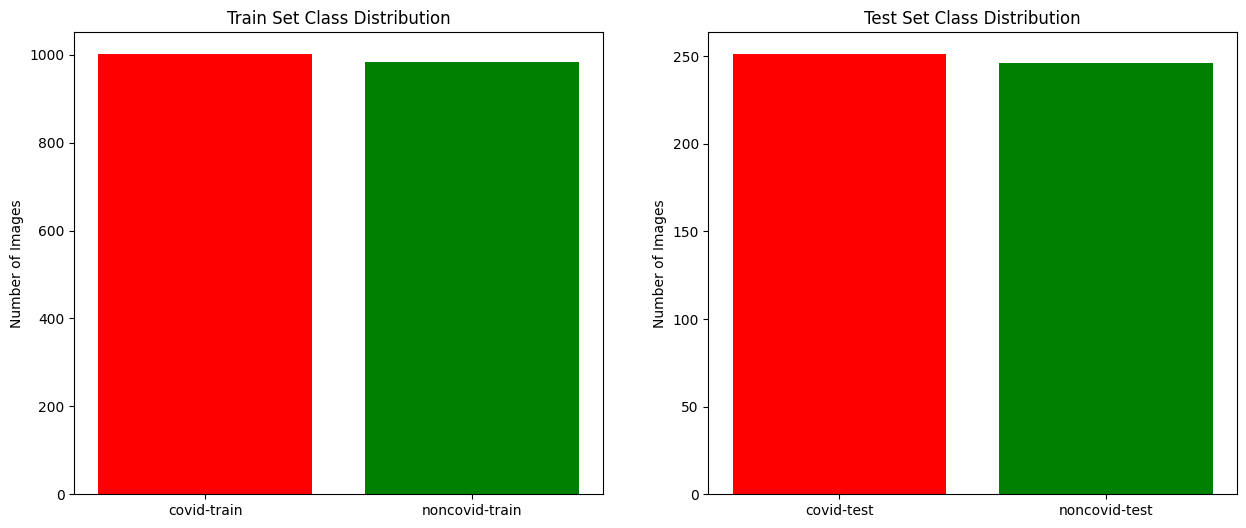

In [ ]:
# Class Distribution in Train Set
train_labels = ['covid-train', 'noncovid-train']
train_counts = [covid_train_count, noncovid_train_count]

# Class Distribution in Test Set
test_labels = ['covid-test', 'noncovid-test']
test_counts = [covid_test_count, noncovid_test_count]

# Plotting the distribution
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Train Distribution
ax[0].bar(train_labels, train_counts, color=['red', 'green'])
ax[0].set_title('Train Set Class Distribution')
ax[0].set_ylabel('Number of Images')

# Test Distribution
ax[1].bar(test_labels, test_counts, color=['red', 'green'])
ax[1].set_title('Test Set Class Distribution')
ax[1].set_ylabel('Number of Images')

plt.show()


##  Display Sample Images

In [ ]:
def show_samples(image_paths, title, n=5):
    plt.figure(figsize=(15, 5))
    for i in range(n):
        img = Image.open(image_paths[i])
        img = img.convert("RGB")  # Ensure it's RGB
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(f"{title} Sample {i+1}")
        plt.axis('off')
    plt.show()

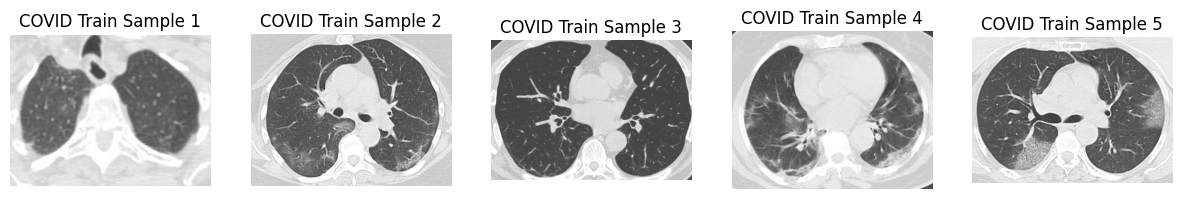

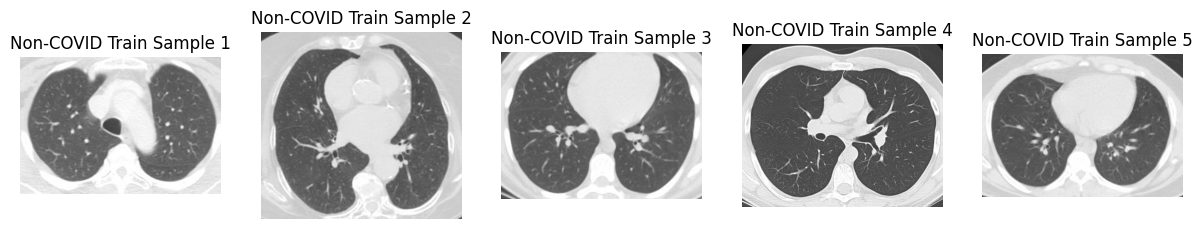

In [ ]:
# Show 5 samples from COVID and Non-COVID train data
covid_train_images = [os.path.join(train_dir, "covid-train", f) for f in os.listdir(os.path.join(train_dir, "covid-train"))]
noncovid_train_images = [os.path.join(train_dir, "noncovid-train", f) for f in os.listdir(os.path.join(train_dir, "noncovid-train"))]

show_samples(covid_train_images, "COVID Train")
show_samples(noncovid_train_images, "Non-COVID Train")

## Image Size Distribution

this ensures that images are of same sizes or if they need to be resized

In [ ]:
# Collect image dimensions
image_sizes = []

for img_name in covid_train_images[:50] + noncovid_train_images[:50]:  # Limit to first 50 for speed
    with Image.open(img_name) as img:
        image_sizes.append(img.size)

sizes_df = pd.DataFrame(image_sizes, columns=['Width', 'Height'])
print(sizes_df.describe())

            Width      Height
count  100.000000  100.000000
mean   348.610000  259.980000
std     50.300892   48.870263
min    200.000000  138.000000
25%    326.250000  228.500000
50%    355.000000  259.000000
75%    382.000000  290.000000
max    455.000000  357.000000


1. count

Width: 100

Height: 100

This shows that there are 100 data points for both width and height. This indicates that the dataset contains information about 100 images.

2. mean

Width: 348.61

Height: 259.98
The mean (or average) value of the widths is 348.61 pixels, and the average height is 259.98 pixels. These are the average dimensions of the images in your dataset.

3. std (Standard Deviation)

Width: 50.30

Height: 48.97

The standard deviation tells us how much the data varies from the mean. A high standard deviation means the values are spread out, while a low standard deviation means they are clustered around the mean.

The width has a standard deviation of 50.30, meaning the width of most images varies by about 48 pixels from the average width of 348.61 pixels.

The height has a standard deviation of  48.97, meaning the height of most images varies by about 47 pixels from the average height of 259.98 pixels.

4. min (Minimum)

Width: 200

Height: 138

These are the minimum values for width and height. The smallest image width is 200 pixels, and the smallest image height is 138 pixels.

5. 25% (1st Quartile / 25th Percentile)

Width: 326

Height: 228

The 25th percentile (or 1st quartile) is the value below which 25% of the data falls. In this case:

25% of the images have a width less than 326 pixels.

25% of the images have a height less than 228 pixels.

6. 50% (Median / 2nd Quartile)

Width: 355

Height: 259

The 50th percentile is the median, which means half of the values are below this point and half are above it.

The median width of the images is 355 pixels.

The median height of the images is 259 pixels.

7. 75% (3rd Quartile / 75th Percentile)

Width: 282

Height: 290

The 75th percentile is the value below which 75% of the data falls. In this case:

75% of the images have a width less than 282 pixels.

75% of the images have a height less than 290 pixels.

8. max (Maximum)

Width: 455

Height: 357

These are the maximum values for width and height. The largest image width is 455 pixels, and the largest image height is 357 pixels.

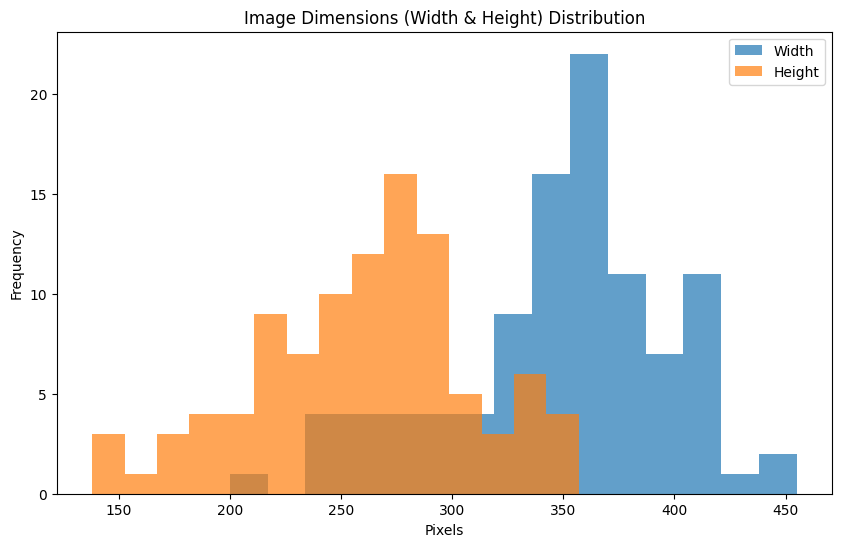

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(sizes_df['Width'], alpha=0.7, label='Width', bins=15)
plt.hist(sizes_df['Height'], alpha=0.7, label='Height', bins=15)
plt.legend()
plt.title('Image Dimensions (Width & Height) Distribution')
plt.xlabel('Pixels')
plt.ylabel('Frequency')
plt.show()

here, we see that resizing is required as images sizes vary and standard deviation is high

## resizing of images and storing them into diffrent sub folders

In [ ]:
from PIL import Image
import os

def resize_images(src_dir, dest_dir, target_size=(224, 224)):
    # Ensure the destination directory exists
    if not os.path.exists(dest_dir):
        os.makedirs(dest_dir)

    # Iterate through all files in the source directory
    for file_name in os.listdir(src_dir):
        file_path = os.path.join(src_dir, file_name)

        # Open image, resize it, and save it to the destination directory
        with Image.open(file_path) as img:
            img_resized = img.resize(target_size)
            img_resized.save(os.path.join(dest_dir, file_name))

In [ ]:
resize_images("/content/ct-scans/train/covid-train", "/content/ct-scans/train/covid-train-resized", target_size=(224, 224))
resize_images("/content/ct-scans/train/noncovid-train", "/content/ct-scans/train/noncovid-train-resized", target_size=(224, 224))

resize_images("/content/ct-scans/test/covid-test", "/content/ct-scans/test/covid-test-resized", target_size=(224, 224))
resize_images("/content/ct-scans/test/noncovid-test", "/content/ct-scans/test/noncovid-test-resized", target_size=(224, 224))


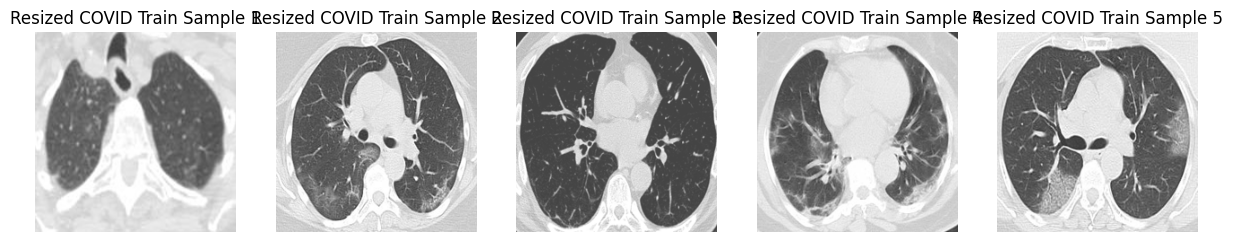

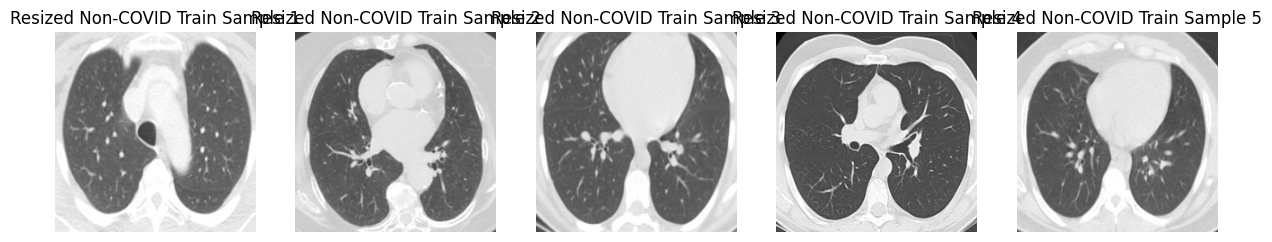

In [ ]:
# Get the file paths for resized COVID and Non-COVID train images
resized_covid_train_images = [os.path.join("/content/ct-scans/train/covid-train-resized", f) for f in os.listdir("/content/ct-scans/train/covid-train-resized")]
resized_noncovid_train_images = [os.path.join("/content/ct-scans/train/noncovid-train-resized", f) for f in os.listdir("/content/ct-scans/train/noncovid-train-resized")]

# Show 5 samples from resized COVID and Non-COVID train images
show_samples(resized_covid_train_images, "Resized COVID Train")
show_samples(resized_noncovid_train_images, "Resized Non-COVID Train")


## Grayscale vs RGB Check

In [ ]:
def check_image_mode(image_paths):
    modes = []
    for path in image_paths[:10]:  # Check first 10 images for brevity
        with Image.open(path) as img:
            modes.append(img.mode)
    return set(modes)  # Return unique modes

In [ ]:
# Get the file paths for resized COVID and Non-COVID train images
resized_covid_train_images = [os.path.join("/content/ct-scans/train/covid-train-resized", f) for f in os.listdir("/content/ct-scans/train/covid-train-resized")]
resized_noncovid_train_images = [os.path.join("/content/ct-scans/train/noncovid-train-resized", f) for f in os.listdir("/content/ct-scans/train/noncovid-train-resized")]

# Check modes for resized train images
print("Resized Train images mode check (first 10):", check_image_mode(resized_covid_train_images + resized_noncovid_train_images))


Resized Train images mode check (first 10): {'RGB', 'RGBA'}


here, we see that the first 10 images have two diffrent modes RGBA and RGB. We should convert this to RGB to maintain consitency in model training

## convert images to RGB

In [ ]:
def convert_to_rgb(image_paths, target_dir):
    # Ensure the destination directory exists
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)

    # Convert all images to RGB and save them
    for file_name in os.listdir(image_paths):
        file_path = os.path.join(image_paths, file_name)
        with Image.open(file_path) as img:
            rgb_img = img.convert("RGB")  # Convert image to RGB
            rgb_img.save(os.path.join(target_dir, file_name))

In [ ]:
# Convert resized COVID and Non-COVID train images to RGB
convert_to_rgb("/content/ct-scans/train/covid-train-resized", "/content/ct-scans/train/covid-train-resized-rgb")
convert_to_rgb("/content/ct-scans/train/noncovid-train-resized", "/content/ct-scans/train/noncovid-train-resized-rgb")

# Convert resized test images to RGB
convert_to_rgb("/content/ct-scans/test/covid-test-resized", "/content/ct-scans/test/covid-test-resized-rgb")
convert_to_rgb("/content/ct-scans/test/noncovid-test-resized", "/content/ct-scans/test/noncovid-test-resized-rgb")

In [ ]:
# Get the file paths for resized and converted RGB COVID and Non-COVID train images
resized_rgb_covid_train_images = [os.path.join("/content/ct-scans/train/covid-train-resized-rgb", f) for f in os.listdir("/content/ct-scans/train/covid-train-resized-rgb")]
resized_rgb_noncovid_train_images = [os.path.join("/content/ct-scans/train/noncovid-train-resized-rgb", f) for f in os.listdir("/content/ct-scans/train/noncovid-train-resized-rgb")]

# Check modes for resized and converted RGB train images
print("Resized RGB Train images mode check (first 10):", check_image_mode(resized_rgb_covid_train_images + resized_rgb_noncovid_train_images))


Resized RGB Train images mode check (first 10): {'RGB'}


## data augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,       # Normalize pixel values between 0 and 1
    rotation_range=30,    # Random rotation
    width_shift_range=0.2, # Random width shift
    height_shift_range=0.2, # Random height shift
    shear_range=0.2,      # Random shear transformation
    zoom_range=0.2,       # Random zoom
    horizontal_flip=True, # Random horizontal flip
    fill_mode='nearest'   # Fill in missing pixels after transformations
)

test_datagen = ImageDataGenerator(rescale=1./255) # Only rescale for test data


we do not apply apply augementation on test data (except for rescale) because the test data represents the real world data which should not be modified artifically

In [ ]:
train_generator = train_datagen.flow_from_directory(
    '/content/ct-scans/train',  # Train directory with resized images
    target_size=(224, 224),    # Image size
    batch_size=32,
    class_mode='binary'        # Binary classification (COVID vs Non-COVID)
)

test_generator = test_datagen.flow_from_directory(
    '/content/ct-scans/test',   # Test directory with resized images
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

Found 5952 images belonging to 6 classes.
Found 1491 images belonging to 6 classes.


this would generate 6 classes as there are six folders in both test and train. As this is a binary classification (ie covid and Non covid) so we need only two classes. This could be achieved by deleting the unessary folders

In [ ]:
import shutil

# Delete unnecessary folders
shutil.rmtree('/content/ct-scans/train/covid-train')
shutil.rmtree('/content/ct-scans/train/covid-train-resized')
shutil.rmtree('/content/ct-scans/train/noncovid-train')
shutil.rmtree('/content/ct-scans/train/noncovid-train-resized')
shutil.rmtree('/content/ct-scans/test/covid-test')
shutil.rmtree('/content/ct-scans/test/noncovid-test')
shutil.rmtree('/content/ct-scans/test/noncovid-test-resized')


In [ ]:
shutil.rmtree('/content/ct-scans/test/covid-test-resized')

rename the folders so that the datagenerator can classify images easily

In [ ]:
# use this block of cell only once to rename the folders
# import os

# # Paths
# base_train_path = '/content/ct-scans/train'
# base_test_path = '/content/ct-scans/test'

# # Renaming train folders
# os.rename(os.path.join(base_train_path, 'covid-train-resized-rgb'), os.path.join(base_train_path, 'covid'))
# os.rename(os.path.join(base_train_path, 'noncovid-train-resized-rgb'), os.path.join(base_train_path, 'noncovid'))

# # Renaming test folders
# os.rename(os.path.join(base_test_path, 'covid-test-resized-rgb'), os.path.join(base_test_path, 'covid'))
# os.rename(os.path.join(base_test_path, 'noncovid-test-resized-rgb'), os.path.join(base_test_path, 'noncovid'))


FileNotFoundError: [Errno 2] No such file or directory: '/content/ct-scans/train/covid-train-resized-rgb' -> '/content/ct-scans/train/covid'

In [ ]:
print(train_generator.class_indices)
print(test_generator.class_indices)


{'covid': 0, 'noncovid': 1}
{'covid': 0, 'noncovid': 1}


In [ ]:
train_generator = train_datagen.flow_from_directory(
    '/content/ct-scans/train',
    target_size=(224, 224),
    batch_size=20,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    '/content/ct-scans/test',
    target_size=(224, 224),
    batch_size=20,
    class_mode='binary'
)

# Double check mapping
print(train_generator.class_indices)
print(test_generator.class_indices)


Found 1984 images belonging to 2 classes.
Found 497 images belonging to 2 classes.
{'covid': 0, 'noncovid': 1}
{'covid': 0, 'noncovid': 1}


# 3] model training and compiling

## model selection

In [ ]:
from tensorflow.keras import models, layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model.add(layers.Dropout(0.5))  # Add Dropout layer
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=1e-4),
              metrics=['accuracy'])

model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,679,041 (36.92 MB)

 Trainable params: 9,679,041 (36.92 MB)

 Non-trainable params: 0 (0.00 B)

## use EarlyStopping to prevent overfitting

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True, verbose=1)




## model training

In [ ]:
# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=100,  # Adjust based on your dataset
    epochs=30,
    validation_data=test_generator,  # Use the test generator as the validation set
    validation_steps=10,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.5372 - loss: 0.9630
Epoch 1: val_loss improved from inf to 0.74392, saving model to best_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 28s 281ms/step - accuracy: 0.5374 - loss: 0.9622 - val_accuracy: 0.7100 - val_loss: 0.7439
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.5751 - loss: 0.7589
Epoch 2: val_loss improved from 0.74392 to 0.73446, saving model to best_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 410ms/step - accuracy: 0.5754 - loss: 0.7587 - val_accuracy: 0.5150 - val_loss: 0.7345
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.6094 - loss: 0.7100
Epoch 3: val_loss improved from 0.73446 to 0.62617, saving model to best_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 411ms/step - accuracy: 0.6095 - loss: 0.7098 - val_accuracy: 0.7100 - val_loss: 0.6262
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.6081 - loss: 0.6755
Epoch 4: val_loss improved from 0.626

# 4] model evaluation

In [ ]:
# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(test_generator)
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy}')


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.8691 - loss: 0.3969
Test Loss: 0.38915619254112244
Test Accuracy: 0.863179087638855


Test Accuracy: ~86.31%

Test Loss: ~0.38

Train Accuracy: ~86.91%

## plotting accuracy and loss

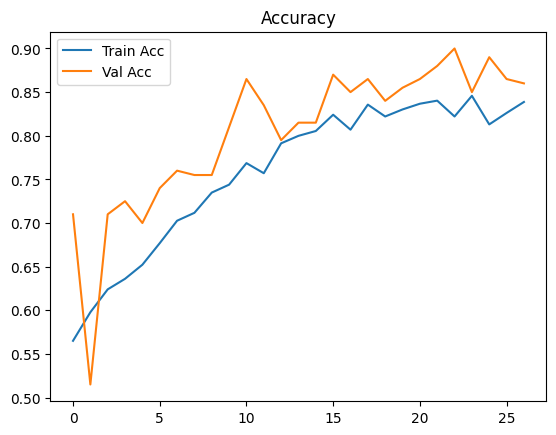

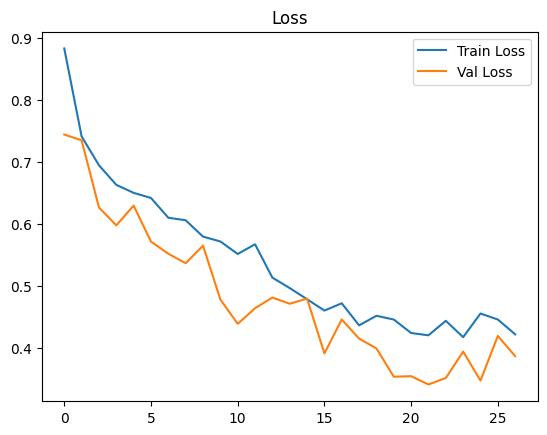

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()
